We're going to run a grid of stars from 15+ solar masses for a range of metallicities to assess what masses lead to BH formation in COSMIC.

In [4]:
from cosmic.sample.initialbinarytable import InitialBinaryTable
from cosmic.evolve import Evolve
import numpy as np
import matplotlib.pyplot as plt
import cogsworth
from multiprocessing import Pool
import pandas as pd

%config InlineBackend.figure_format = 'retina'

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [2]:
from cogsworth.utils import default_BSE_settings

Create two grids to handle most metallicities and high metallicities separately

In [92]:
initial_binaries = None

for step, m_min, m_max, Z_min, Z_max in [
    (0.025, 16, 22, 1e-4, 2e-2),
    (0.5, 22, 90, 1.6e-2, 0.03),
]:

    mass_range = np.arange(m_min, m_max + step, step)
    metallicity_grid = np.geomspace(1e-4, 0.03, 200)
    metallicity_grid = metallicity_grid[(metallicity_grid >= Z_min) & (metallicity_grid <= Z_max)]

    M, Z = np.meshgrid(mass_range, metallicity_grid, indexing='ij')
    m_flat = M.ravel()
    z_flat = Z.ravel()
    binaries = InitialBinaryTable.InitialBinaries(
        m1=M.ravel(),
        m2=np.zeros(len(m_flat)),
        porb=-1 * np.ones(len(m_flat)),
        ecc=-1 * np.ones(len(m_flat)),
        tphysf=13700 * np.ones(len(m_flat)),
        kstar1=np.ones(len(m_flat)),
        kstar2=np.zeros(len(m_flat)),
        metallicity=z_flat,
    )
    
    if initial_binaries is None:
        initial_binaries = binaries
    else:
        initial_binaries = pd.concat([initial_binaries, binaries], ignore_index=True)

initial_binaries.sort_values(by='metallicity', inplace=True)

len(initial_binaries)

47599

In [93]:
with Pool(32) as pool:
    bpp, bcm, initC, kick_info = Evolve.evolve(initial_binaries, pool=pool, BSEDict=default_BSE_settings)
final_bpp = bpp.drop_duplicates(subset="bin_num", keep="last")

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cosmic/evolve.py:286: UserWarning: The value for binfrac in initial binary table is being overwritten by the value of binfrac from either the params file or the BSEDict.
  warnings.warn("The value for {0} in initial binary table is being "


In [94]:
# find the minimum initial mass in initC where final_bpp has kstar_1 == 13
exploding_stars = final_bpp[final_bpp["kstar_1"] == 14]
exploding_initC = initC[initC["bin_num"].isin(exploding_stars["bin_num"])]
min_exploding_mass = exploding_initC.groupby("metallicity")["mass_1"].min().reset_index()
min_exploding_mass.to_hdf("~/ceph/underworld/cosmic_bh_crit.h5", key="min_bh_mass", mode="w")

<Axes: title={'center': 'Minimum Initial Mass for Core-Collapse vs Metallicity'}, xlabel='Metallicity', ylabel='Minimum Initial Mass for Core-Collapse (M$_\\odot$)'>

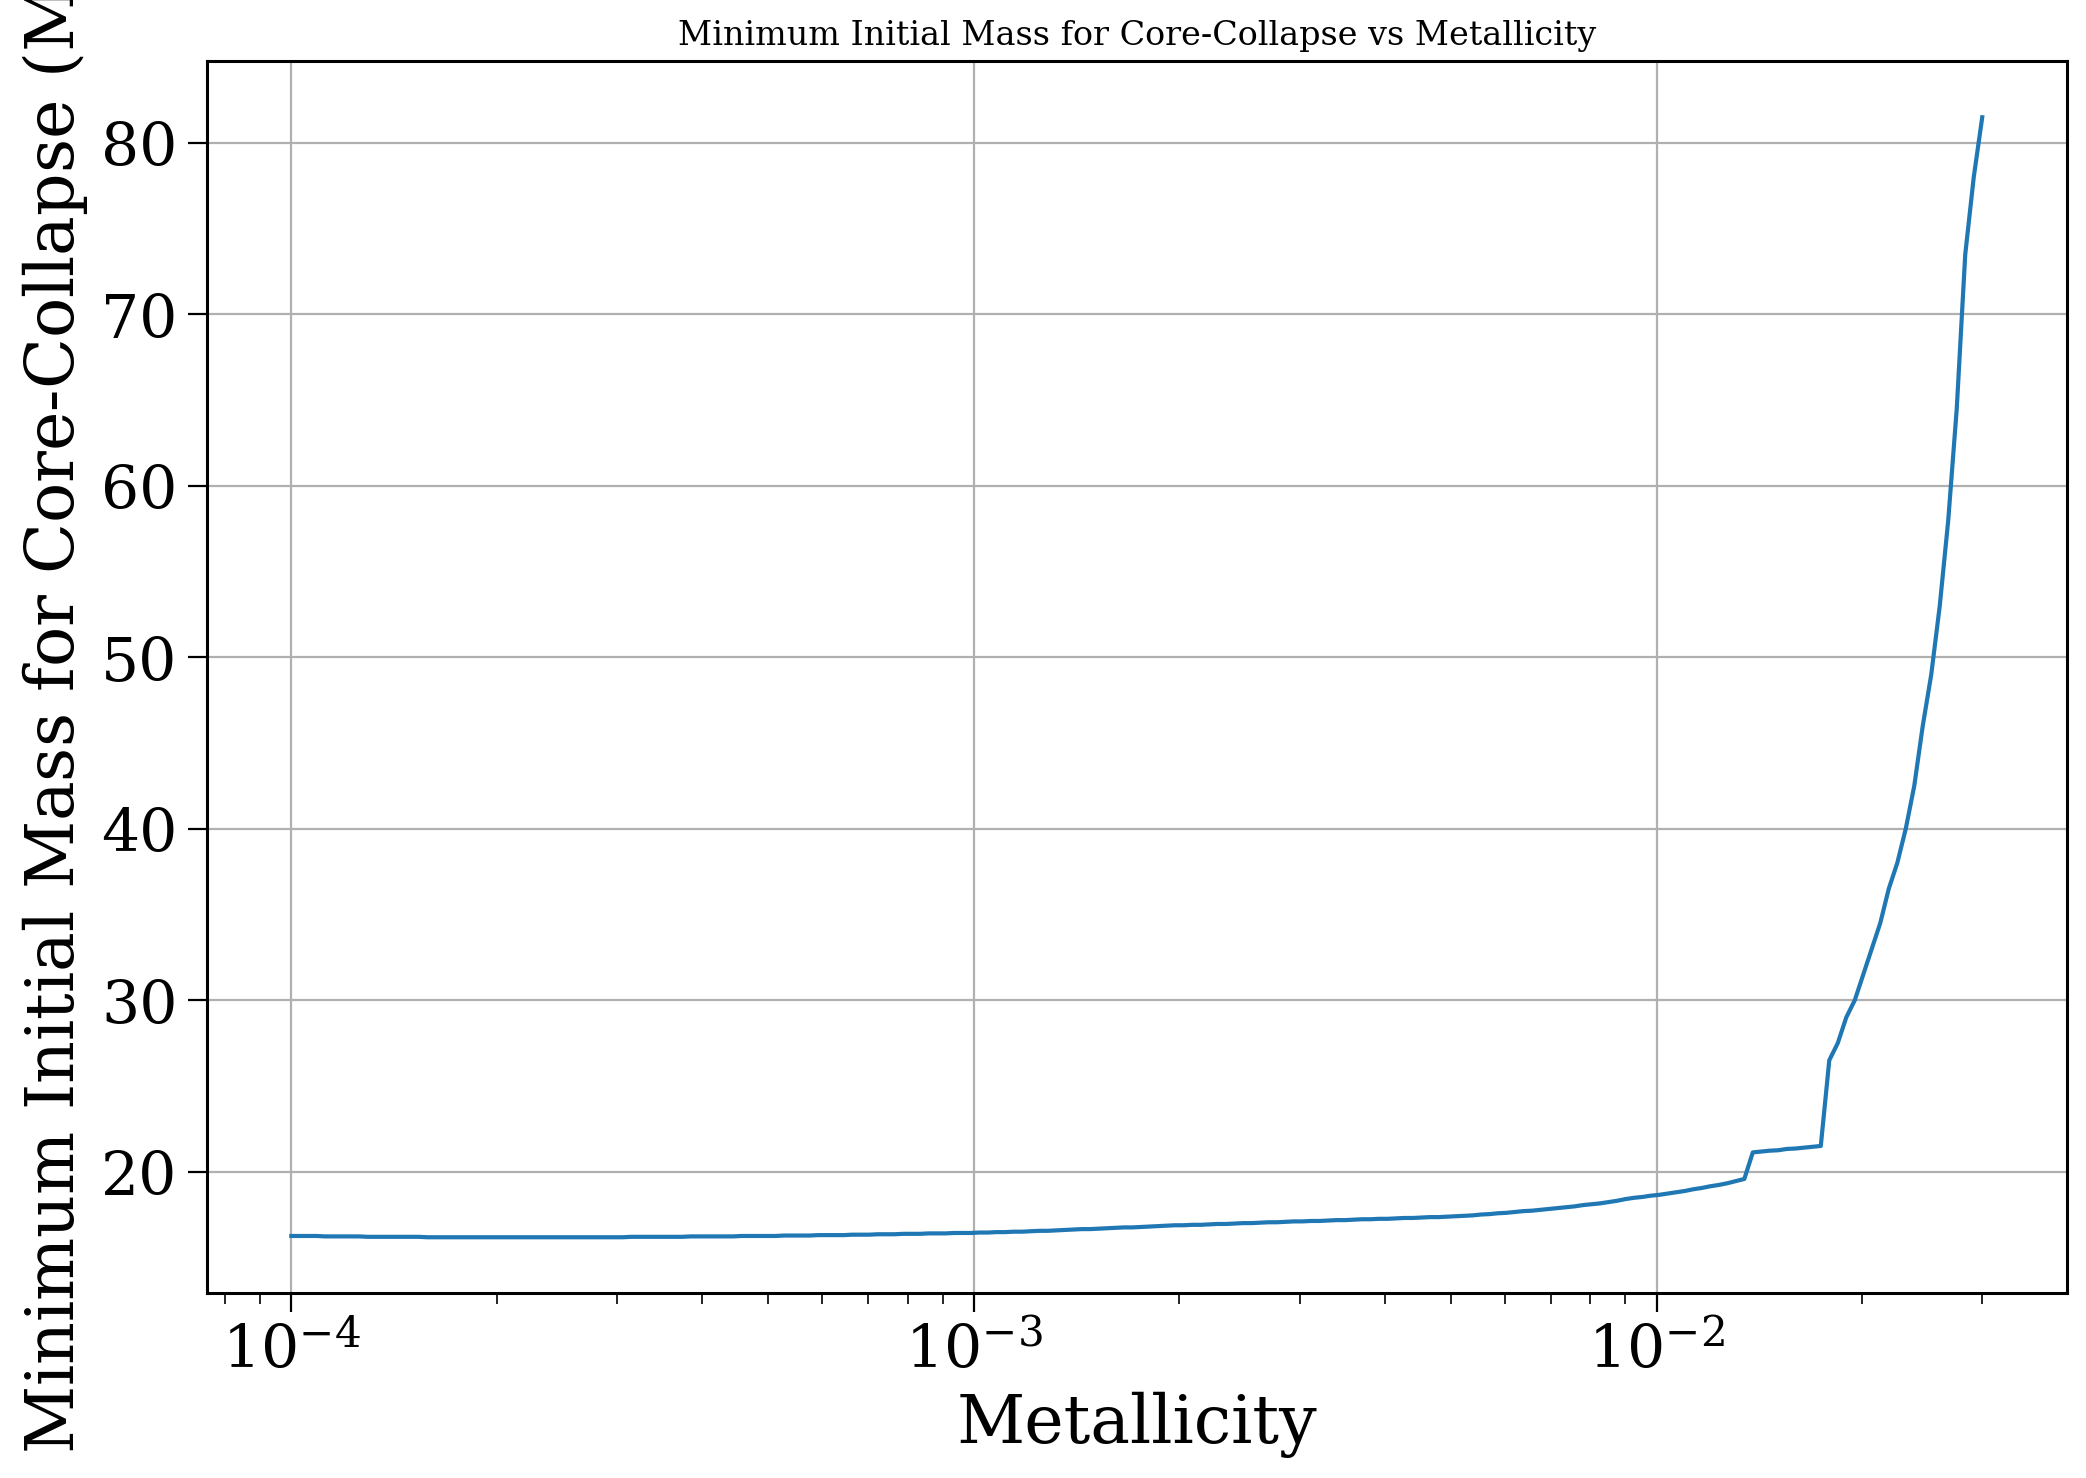

In [95]:
min_exploding_mass.plot(
    x="metallicity",
    y="mass_1",
    logx=True,
    xlabel="Metallicity",
    ylabel="Minimum Initial Mass for Core-Collapse (M$_\odot$)",
    title="Minimum Initial Mass for Core-Collapse vs Metallicity",
    legend=False,
    grid=True,
)

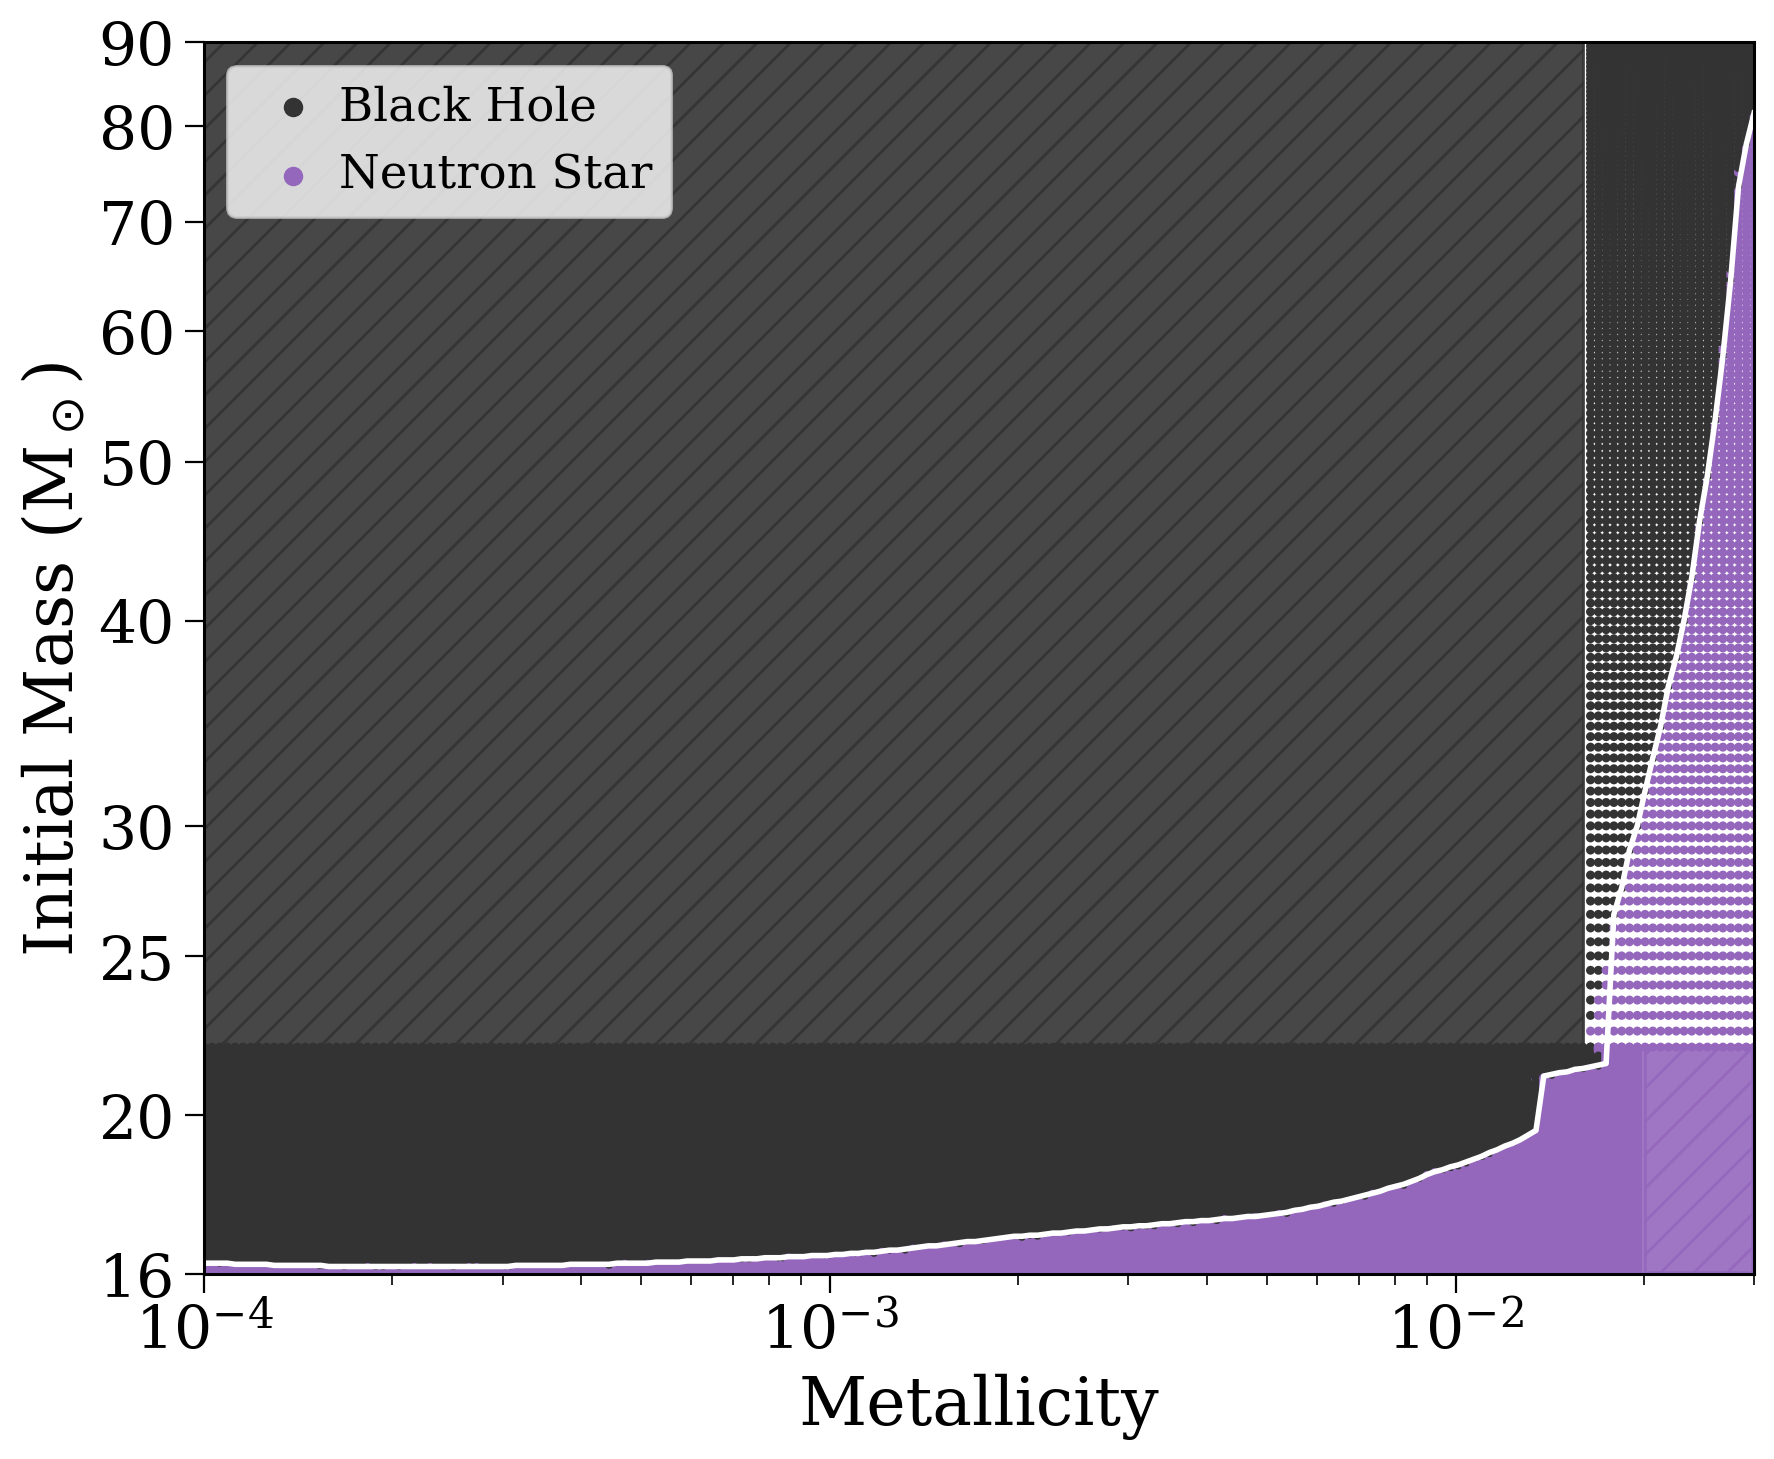

In [103]:
fig, ax = plt.subplots(figsize=(10, 8))

colours = [("#333" if k == 14 else "tab:purple") for k in final_bpp['kstar_1']]

ax.scatter(initC["metallicity"], initC["mass_1"],
           c=colours,
           s=5,
           rasterized=True)

ax.plot(min_exploding_mass["metallicity"], min_exploding_mass["mass_1"],
        color='white', lw=2)

ax.fill_between(
    [1e-4, 1.6e-2],
    [22, 22],
    [90, 90],
    color='#333',
    hatch='//',
    alpha=.9
)

ax.fill_between(
    [2e-2, 0.03],
    [16, 16],
    [22, 22],
    color='tab:purple',
    hatch='//',
    alpha=.9,
    lw=2
)

# ax.fill_between(

# ax.annotate('All form black holes', xy=(0.5, 0.5), xycoords='axes fraction',
#             fontsize=0.5*fs, color='white', ha='center', va='bottom')
# ax.annotate('All Core-Collapse', xy=(0.5, 0.99), xycoords='axes fraction',
#             fontsize=0.5*fs, color='white', ha='center', va='top')

for k in [14, 13]:
    ax.scatter(
        np.nan, np.nan,
        c="#333" if k == 14 else "tab:purple",
        label=cogsworth.utils.kstar_translator[k]["long"],
    )

ax.legend(loc='upper left', handletextpad=0.0, ncol=1)

ax.set(
    xlabel="Metallicity",
    ylabel="Initial Mass (M$_\odot$)",
    xscale="log",
    yscale="log",
    xlim=(1e-4, 0.03),
    ylim=(16, 90),
)

ax.set_yticks([16, 20, 25, 30, 40, 50, 60, 70, 80, 90])
ax.set_yticklabels([16, 20, 25, 30, 40, 50, 60, 70, 80, 90])

# plt.savefig("../plots/cosmic_bh_crit.pdf", format="pdf", bbox_inches='tight')
plt.show()

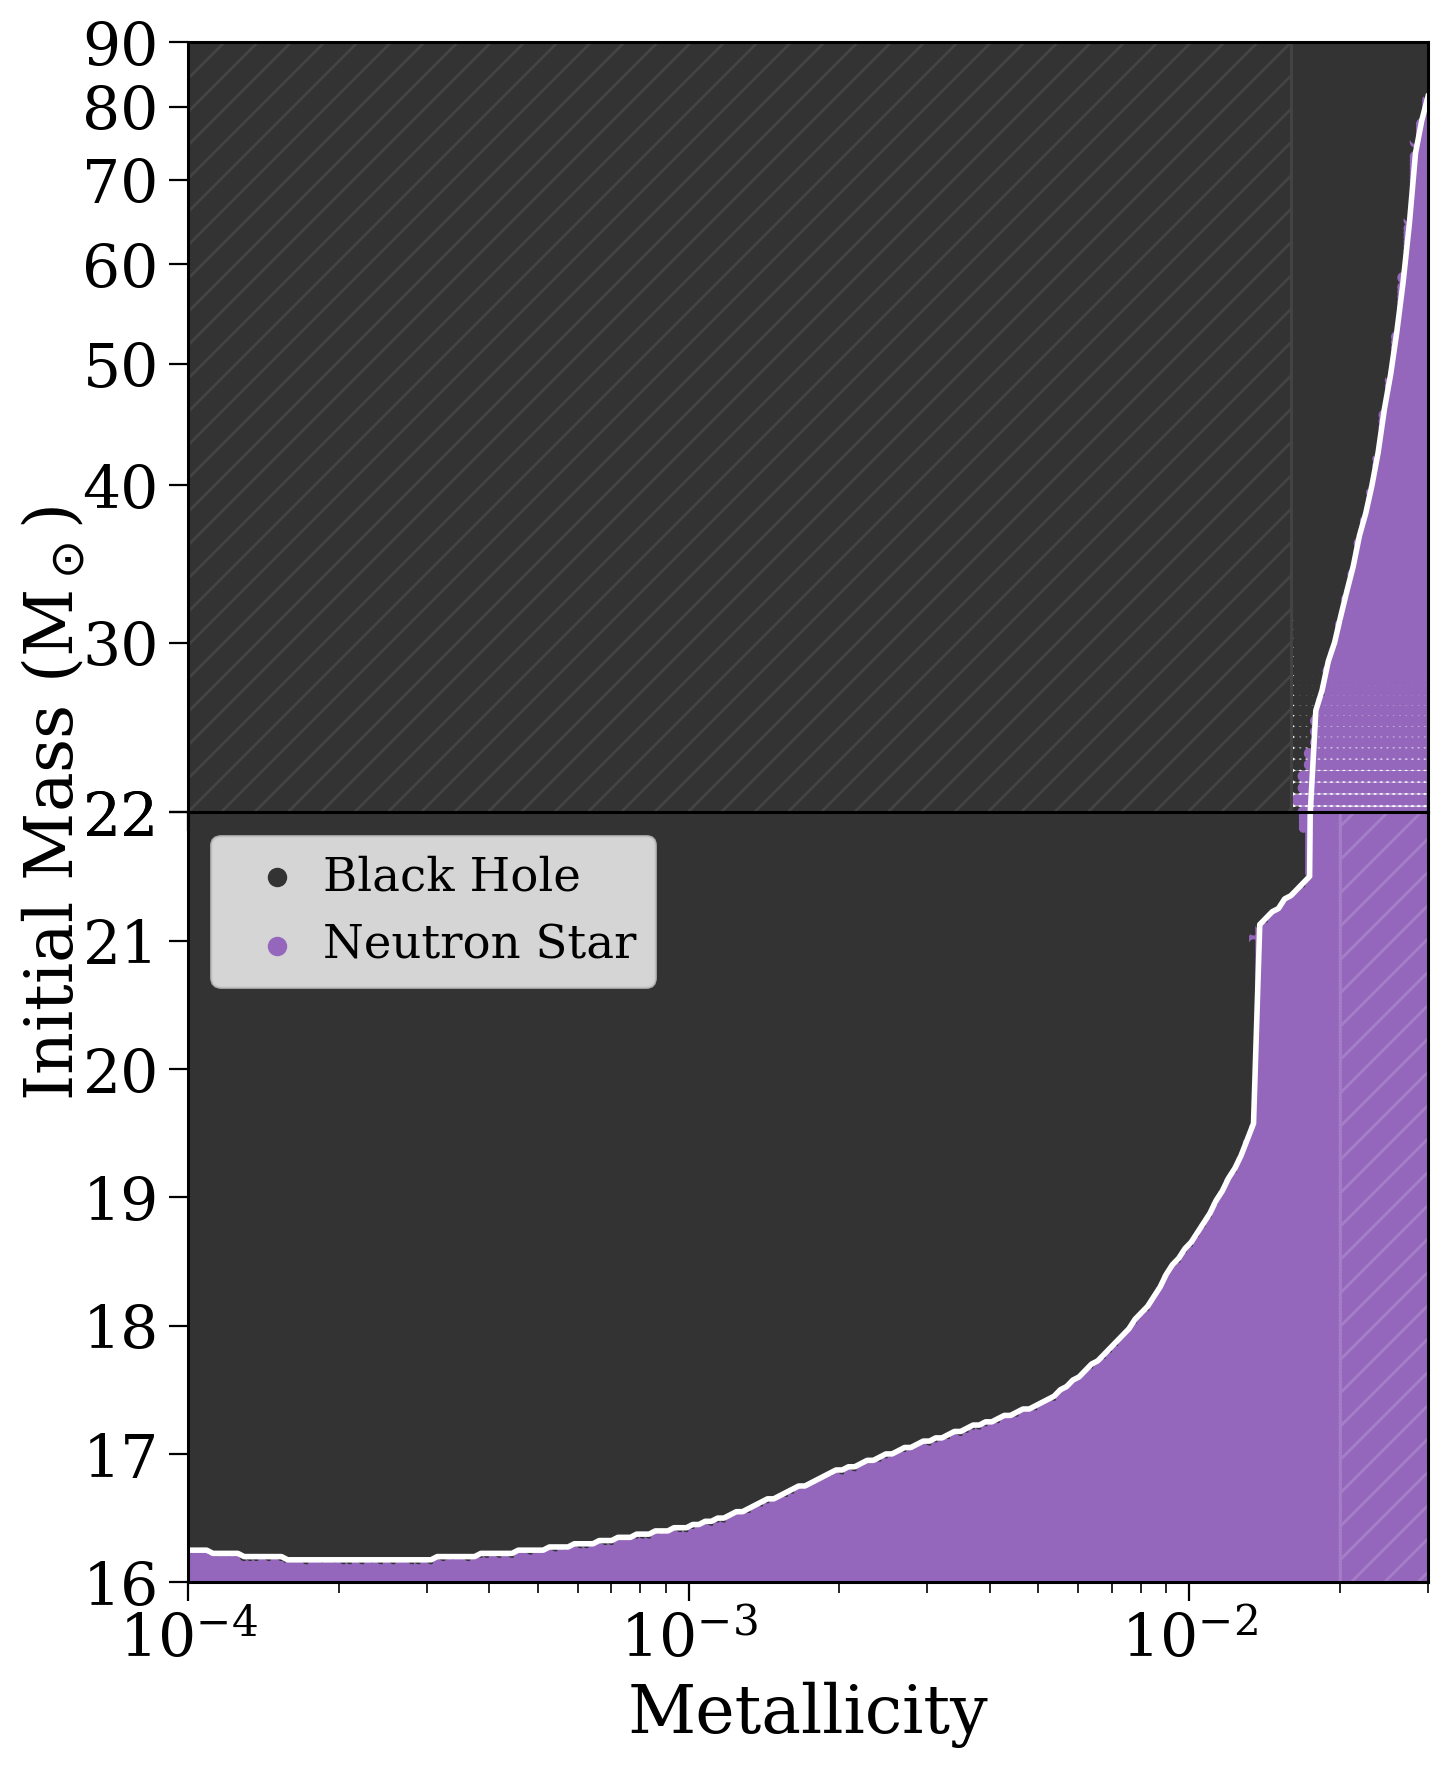

In [134]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
colours = [("#333" if k == 14 else "tab:purple") for k in final_bpp['kstar_1']]

fig.subplots_adjust(hspace=0.0)

for ax, m_lims, scale, s in zip(axes, [(22, 90), (16, 22)], ['log', 'linear'], [10, 5]):
    ax.scatter(initC["metallicity"], initC["mass_1"],
            c=colours,
            s=s,
            rasterized=True)

    ax.plot(min_exploding_mass["metallicity"], min_exploding_mass["mass_1"],
            color='white', lw=2)

    ax.fill_between(
        [1e-4, 1.6e-2],
        [22, 22],
        [90, 90],
        color='#333',
    )
    ax.fill_between(
        [1e-4, 1.6e-2],
        [22, 22],
        [90, 90],
        facecolor='none',
        edgecolor='#444',
        hatch='//',
    )

    ax.fill_between(
        [2e-2, 0.03],
        [16, 16],
        [22, 22],
        color='tab:purple',
    )
    ax.fill_between(
        [2e-2, 0.03],
        [16, 16],
        [22, 22],
        facecolor='none',
        edgecolor='#a47ec7',
        hatch='//',
    )

    for k in [14, 13]:
        ax.scatter(
            np.nan, np.nan,
            c="#333" if k == 14 else "tab:purple",
            label=cogsworth.utils.kstar_translator[k]["long"],
        )

    ax.set(
        xlabel="Metallicity" if ax == axes[-1] else "",
        # ylabel="Initial Mass (M$_\odot$)",
        xscale="log",
        yscale=scale,
        xlim=(1e-4, 0.03),
        ylim=m_lims,
    )

axes[0].set_yticks([22, 30, 40, 50, 60, 70, 80, 90])
axes[0].set_yticklabels([22, 30, 40, 50, 60, 70, 80, 90])
axes[1].legend(loc='upper left', handletextpad=0.0, ncol=1)

fig.supylabel("Initial Mass (M$_\odot$)", fontsize=fs)

plt.savefig("../plots/cosmic_bh_crit.pdf", format="pdf", bbox_inches='tight')
plt.show()